# approval

In [9]:
from typing import TypedDict, Annotated, List, Optional, Iterable
from langgraph.graph import add_messages, StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
import json

import os
os.makedirs("logs", exist_ok=True)
import sys
import logging
logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    datefmt='%Y-%m-%d %H:%M:%S',
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler(filename='logs/human_in_the_loop.log', mode='a')
    ]
)
logger = logging.getLogger(__name__)

from dotenv import load_dotenv
load_dotenv()

True

In [10]:
MODEL = "gemini-2.5-flash"
TEMPERATURE = 0.1
MAX_SEARCH_RESULTS = 2

In [11]:
class ChatState(TypedDict):
    messages: Annotated[List, add_messages]

class Chatbot:
    def __init__(
            self,
            model: str = MODEL,
            temperature: float = TEMPERATURE,
            max_search_results: int = MAX_SEARCH_RESULTS,
            interrupt_before: Optional[str] = None,
    ):
        self.memory = MemorySaver()
        self.search_tool = TavilySearchResults(max_results=max_search_results)
        self.tools = [self.search_tool]
        self.llm = ChatGoogleGenerativeAI(model=model, temperature=temperature)
        self.llm_with_tools = self.llm.bind_tools(tools=self.tools)
        self.app = self._build_graph(interrupt_before=interrupt_before or ['tools'])

    # === internal graph nodes functions ===
    def _model(self, state: ChatState):
        response = {
            'messages': [self.llm_with_tools.invoke(state['messages'])]
        }
        logger.debug(f"⬅️ Model response: {response}")

        return response

    def _tool_router(self, state: ChatState):
        last_msg = state['messages'][-1]
        if hasattr(last_msg, 'tool_calls') and len(getattr(last_msg, 'tool_calls', [])) > 0:
            return 'tools'
        else:
            return END
        
    def _build_graph(self, interrupt_before: List[str]):
        graph = StateGraph(ChatState)

        graph.add_node('model', self._model)
        graph.add_node('tools', ToolNode(tools=self.tools))

        graph.set_entry_point('model')

        graph.add_conditional_edges('model', self._tool_router)
        graph.add_edge('tools', 'model')
        
        res = graph.compile(checkpointer=self.memory, interrupt_before=interrupt_before)
        logger.info("✅ Compiled StateGraph")

        return res
   
    # === helper functions ===
    def _config(self, thread_id: str | int):
        res = {
            "configurable": {
                "thread_id": str(thread_id)
            }
        }
        logger.debug(f"Configuration for thread_id {thread_id}: {res}")
        return res

    def send(self, content: str, thread_id: str | int = "1") -> List[BaseMessage]:
        events = self.app.stream(
            {
                "messages": [
                    HumanMessage(content=content)
                ],
            },
            config=self._config(thread_id),
            stream_mode='values'
        )
        last_msg: List[BaseMessage] = []
        for e in events:
            last_msg = e['messages']

        logger.debug(f"💬 Last message (in send function): {last_msg}")
        return last_msg

    def resume(self, thread_id: str | int = "1") -> List[BaseMessage]:
        events = self.app.stream(
            None,
            config=self._config(thread_id),
            stream_mode='values'
        )
        last_msg: List[BaseMessage] = []
        for e in events:
            last_msg = e['messages']

        logger.debug(f"💬 Last message (in resume function): {last_msg}")
        return last_msg
    
    def pending(self, thread_id: str | int = "1") -> Optional[Iterable[str]]:
        snapshot = self.app.get_state(config=self._config(thread_id))
        
        logger.debug(f"⏸️ Pending snapshot: {snapshot}")
        return snapshot.next
    
    def last_ai_message(self, thread_id: str | int = "1") -> Optional[AIMessage]:
        snapshot = self.app.get_state(config=self._config(thread_id))
        msgs: List[BaseMessage] = snapshot.values.get('messages', [])
        for m in reversed(msgs):
            if isinstance(m, AIMessage):
                logger.debug(f"💬 Last AI message: {m}")
                return m
        logger.debug("💬 No AI message found.")
        return None
    
    def last_conversation(self, thread_id: str | int = "1") -> List[BaseMessage]:
        snapshot = self.app.get_state(config=self._config(thread_id))
        res = snapshot.values.get('messages', [])
        logger.debug(f"💬 Last conversation messages: {res}")
        return res
    
    def interactive_tool_approval(self, thread_id: str | int = "1") -> List[BaseMessage]:
        """
        If tools are pending, ask user to approve each tool call.
        Approved -> resume (tools execute).
        Rejected -> inject refusal message and re-run model without executing tools.
        """
        pending = self.pending(thread_id)
        if not pending or 'tools' not in pending:
            logger.debug("🛠 No tools are pending for approval.")
            print("✅ No tools are pending for approval.")
            raise ValueError("No tools are pending for approval.")
        
        ai_msg = self.last_ai_message(thread_id)
        if not ai_msg or not getattr(ai_msg, 'tool_calls', None):
            logger.debug("🛠 No tool calls found in the last AI message.")
            print("❌ No tool calls found in the last AI message.")
            return self.last_conversation(thread_id)
        
        approvals: List[bool] = []
        print("⚠️ The AI model wants to call the following tools:")
        for idx, tc in enumerate(ai_msg.tool_calls):
            name = tc.get('name')
            args = tc.get('args')
            print(f"\nTool {idx + 1}: {name}")
            print(f"Arguments: {json.dumps(args, indent=2, ensure_ascii=False)}")
            while True:
                user_in = input("Approve this tool call? (y/n): ").strip().lower()
                if user_in in ("y", "n"):
                    approvals.append(user_in == "y")
                    break
                print("Enter y or n.")

        if all(approvals):
            print("👍🏻 All tool calls approved. Executing tools...")
            logger.info("👍🏻 All tool calls approved by user.")
            return self.resume(thread_id=thread_id)
        
        rejected_indices = [i for i, ok in enumerate(approvals) if not ok]
        refused_tools = [ai_msg.tool_calls[i].get("name") for i in rejected_indices]
        refusal_text = (
            "User rejected tool usage for: "
            + ", ".join(refused_tools)
            + ". Provide the best possible answer without executing those tools."
        )
        logger.info(f"👎🏻 Refusal text: {refusal_text}")
        return self.send(refusal_text, thread_id=thread_id)
    
    def show_graph(self):
        try:
            from IPython.display import Image, display
            display(Image(self.app.get_graph().draw_mermaid_png()))
        except ImportError:
            print("❌ IPython is not installed. Cannot display the graph.")

# main function

2025-09-01 18:09:53 | INFO     | __main__ | ✅ Compiled StateGraph
2025-09-01 18:09:53 | DEBUG    | urllib3.connectionpool | Starting new HTTPS connection (1): mermaid.ink:443
2025-09-01 18:09:54 | DEBUG    | urllib3.connectionpool | https://mermaid.ink:443 "GET /img/LS0tCmNvbmZpZzoKICBmbG93Y2hhcnQ6CiAgICBjdXJ2ZTogbGluZWFyCi0tLQpncmFwaCBURDsKCV9fc3RhcnRfXyg8cD5fX3N0YXJ0X188L3A+KQoJbW9kZWwobW9kZWwpCgl0b29scyh0b29sczxoci8+PHNtYWxsPjxlbT5fX2ludGVycnVwdCA9IGJlZm9yZTwvZW0+PC9zbWFsbD4pCglfX2VuZF9fKDxwPl9fZW5kX188L3A+KQoJX19zdGFydF9fIC0tPiBtb2RlbDsKCW1vZGVsIC0tPiBfX2VuZF9fOwoJY2xhc3NEZWYgZGVmYXVsdCBmaWxsOiNmMmYwZmYsbGluZS1oZWlnaHQ6MS4yCgljbGFzc0RlZiBmaXJzdCBmaWxsLW9wYWNpdHk6MAoJY2xhc3NEZWYgbGFzdCBmaWxsOiNiZmI2ZmMK?type=png&bgColor=!white HTTP/1.1" 200 7628


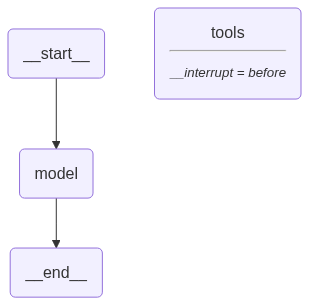

Interactive chat (type 'quit' or 'exit' to stop)

2025-09-01 18:10:05 | DEBUG    | __main__ | Configuration for thread_id 1: {'configurable': {'thread_id': '1'}}
2025-09-01 18:10:08 | DEBUG    | __main__ | ⬅️ Model response: {'messages': [AIMessage(content='I do not know your name. I am a large language model, trained by Google. I do not have access to personal information about you.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--8f0b9ed4-5806-472b-b12f-951cc0ab6185-0', usage_metadata={'input_tokens': 78, 'output_tokens': 29, 'total_tokens': 107, 'input_token_details': {'cache_read': 0}})]}
2025-09-01 18:10:08 | DEBUG    | __main__ | 💬 Last message (in send function): [HumanMessage(content='whats my name?', additional_kwargs={}, response_metadata={}, id='7d8a9a4e-139a-4c70-95db-d3f0e72a7d91'), AIMessage(content='I do not know your name. I 

In [12]:
if __name__ == "__main__":
    bot = Chatbot()
    bot.show_graph()

    print("Interactive chat (type 'quit' or 'exit' to stop)\n")
    thread_id = 1

    while True:
        try:
            user_input = input("You: ").strip()
        except (KeyboardInterrupt, EOFError):
            print("\nExiting.")
            break

        if not user_input:
            continue

        if user_input.lower() in ("quit", "exit"):
            print("Goodbye.")
            break

        msgs = bot.send(user_input, thread_id=thread_id)
        print("AI Draft:")
        print(msgs[-1].pretty_repr())

        pending = bot.pending(thread_id=thread_id)
        if pending and "tools" in list(pending):
            print(f"Interrupted before nodes: {list(pending)}")
            # Human approval loop
            msgs = bot.interactive_tool_approval(thread_id=thread_id)
            print("Final AI Message:")
            print(msgs[-1].pretty_repr())
        else:
            print("No tool execution needed.")